In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,roc_curve,auc,roc_auc_score,confusion_matrix,classification_report

<h2>Read Data</h2>

In [2]:
df=pd.read_csv("./Data/train_data.csv")
df.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized,class
0,4.937605,0.423813,0.894121,0.894121,231.248614,32.252113,0.232233,0.518499,1.458699,0.907496,...,3.548803,12.964904,1.228323,0.423813,0.586963,-0.528501,0.805223,0.976092,0.994058,0
1,2.551722,0.259480,0.871947,0.871947,202.027005,25.453599,0.109989,0.813569,0.644821,0.961702,...,2.583464,7.927913,0.549805,0.259480,0.315387,-0.538252,0.614395,0.989201,0.996550,0
2,6.206039,0.618669,0.881609,0.881609,290.479083,38.493259,0.287417,0.465086,1.622099,0.893214,...,3.951214,16.582751,1.352757,0.618669,0.663400,-0.495262,0.809447,0.971216,0.991679,0
3,1.885596,0.194235,0.828962,0.828962,82.500028,12.126492,0.090015,0.849845,0.524957,0.967822,...,2.379112,5.820273,0.444227,0.194235,0.272537,-0.521013,0.555576,0.991032,0.997319,0
4,4.790395,0.481035,0.890599,0.890599,343.387103,44.837110,0.210380,0.629436,1.159005,0.925256,...,3.366307,14.007415,0.979534,0.481035,0.521808,-0.517051,0.743680,0.979213,0.993550,0


In [3]:
y_train=df[['class']]
X_train=df.drop(labels="class",axis=1)
X_train.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum of sqaures: Variance,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized
0,4.937605,0.423813,0.894121,0.894121,231.248614,32.252113,0.232233,0.518499,1.458699,0.907496,...,5.094305,3.548803,12.964904,1.228323,0.423813,0.586963,-0.528501,0.805223,0.976092,0.994058
1,2.551722,0.259480,0.871947,0.871947,202.027005,25.453599,0.109989,0.813569,0.644821,0.961702,...,2.641339,2.583464,7.927913,0.549805,0.259480,0.315387,-0.538252,0.614395,0.989201,0.996550
2,6.206039,0.618669,0.881609,0.881609,290.479083,38.493259,0.287417,0.465086,1.622099,0.893214,...,6.453880,3.951214,16.582751,1.352757,0.618669,0.663400,-0.495262,0.809447,0.971216,0.991679
3,1.885596,0.194235,0.828962,0.828962,82.500028,12.126492,0.090015,0.849845,0.524957,0.967822,...,1.945784,2.379112,5.820273,0.444227,0.194235,0.272537,-0.521013,0.555576,0.991032,0.997319
4,4.790395,0.481035,0.890599,0.890599,343.387103,44.837110,0.210380,0.629436,1.159005,0.925256,...,4.978558,3.366307,14.007415,0.979534,0.481035,0.521808,-0.517051,0.743680,0.979213,0.993550


<h2>Normalize train data</h2>

In [4]:
scaler=StandardScaler()
columns=X_train.columns
X_train=pd.DataFrame(scaler.fit_transform(X_train),columns=columns)
X_train.head()


,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum of sqaures: Variance,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized
0,0.103789,1.135458,-0.068860,-0.068860,0.631463,1.188720,0.744575,-0.417389,0.552925,-0.584817,...,0.126660,0.142939,0.086579,0.511936,1.135458,0.831089,0.829870,0.635882,-0.686903,-1.076539
1,-0.680372,-0.096930,-0.590980,-0.590980,0.288586,0.518011,-0.536722,0.727370,-0.678133,0.647681,...,-0.672298,-0.704388,-0.627683,-0.687257,-0.096930,-0.518169,0.648174,-0.583856,0.581419,0.209637
2,0.520681,2.596747,-0.363470,-0.363470,1.326454,1.804441,1.322993,-0.624613,0.800081,-0.909542,...,0.569488,0.496156,0.599601,0.731857,2.596747,1.210846,1.449196,0.662878,-1.158663,-2.304490
3,-0.899305,-0.586223,-1.603131,-1.603131,-1.113906,-0.796778,-0.746084,0.868106,-0.859438,0.786830,...,-0.898848,-0.883758,-0.926553,-0.873852,-0.586223,-0.731061,0.969384,-0.959816,0.758550,0.606726
4,0.055406,1.564583,-0.151808,-0.151808,1.947260,2.430295,0.515526,0.013004,0.099613,-0.181000,...,0.088959,-0.017247,0.234410,0.072233,1.564583,0.507380,1.043203,0.242510,-0.384961,-1.338453


<h2>Train decision tree</h2>

In [5]:
model=DecisionTreeClassifier(criterion="gini")
model.fit(X_train,y_train)
print(model.max_depth)

None


In [46]:
test=pd.read_csv("./Data/test_data.csv")
y_test=test['class']
X_test=test.drop(labels="class",axis=1)
X_test=pd.DataFrame(scaler.fit_transform(X_test),columns=columns)
X_test.head()



,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum of sqaures: Variance,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized
0,0.115955,1.152092,-0.063260,-0.063260,0.663416,1.257780,0.755880,-0.444491,0.569418,-0.598628,...,0.138458,0.159867,0.101277,0.529910,1.152092,0.854109,0.827370,0.661432,-0.698731,-1.088670
1,-0.644152,-0.067471,-0.570890,-0.570890,0.305115,0.562541,-0.506573,0.703553,-0.656922,0.618894,...,-0.635841,-0.669291,-0.590586,-0.667035,-0.067471,-0.496450,0.648385,-0.589191,0.551824,0.181128
2,0.520059,2.598176,-0.349695,-0.349695,1.389672,1.896021,1.325791,-0.652310,0.815626,-0.919408,...,0.567620,0.505509,0.598211,0.749419,2.598176,1.234232,1.437455,0.689112,-1.163883,-2.300985
3,-0.856370,-0.551674,-1.554955,-1.554955,-1.160467,-0.800335,-0.712855,0.844693,-0.837531,0.756352,...,-0.855399,-0.844815,-0.880083,-0.853280,-0.551674,-0.709546,0.964802,-0.974671,0.726473,0.573161
4,0.069056,1.576752,-0.143906,-0.143906,2.038404,2.544765,0.530200,-0.012862,0.117843,-0.199718,...,0.101922,0.003116,0.244472,0.091031,1.576752,0.530089,1.037520,0.258099,-0.401019,-1.347249


In [7]:
predictions=model.predict(X_test)

In [37]:
#helper functions
def score(y_test,predictions):
    print(classification_report(y_test,predictions))
    print(pd.DataFrame(predictions).value_counts())
    print("Accuracy score ={score}".format(score=accuracy_score(y_test,predictions)))

def plot_matrix(y_test,predictions,filepath):
    matrix=confusion_matrix(y_test,predictions)
    matrix=matrix.transpose()
    cm_df=pd.DataFrame(matrix,index=["Early Blight","Late Blight","Healthy"],columns=["Early Blight","Late Blight","Healthy"])
    sns.heatmap(cm_df,annot_kws={"size":16},annot=True,fmt="d")
    plt.title("Confusion Matrix for Decision Tree Classifier")
    plt.savefig(filepath,dpi=1200)
    
def plot_roc(y_test,predictions,save_path):
    actual_vals=pd.DataFrame(pd.get_dummies(y_test))
    predictions=pd.DataFrame(pd.get_dummies(predictions))
    print('0: {}'.format(predictions[predictions[0]==1][0].sum()))
    print('1 :{}'.format(predictions[predictions[1]==1][1].sum()))
    print('2 :{}'.format(predictions[predictions[2]==1][2].sum()))
    predictions.head()
    #compute roc curve and roc area for each curve
    fpr=dict()
    tpr=dict()
    roc_auc=dict()
    n_classes=3

    #loop for each class
    for i in range(n_classes):
        fpr[i],tpr[i],_=roc_curve(actual_vals.iloc[:,i],predictions.iloc[:,i])
        roc_auc[i]=auc(fpr[i],tpr[i])
    #micro-average roc curve
    fpr["micro"],tpr["micro"],_=roc_curve(actual_vals.to_numpy().ravel(),predictions.to_numpy().ravel())
    roc_auc["micro"]=auc(fpr["micro"],tpr["micro"])
    
    colors = ['aqua', 'darkorange', 'cornflowerblue']
    #main plotter
    lw=2
    plt.figure(figsize=(10,8))
    plt.plot(fpr["micro"], tpr["micro"],
             label='micro-average ROC curve (area = {0:0.2f})'
                   ''.format(roc_auc["micro"]),
             color='deeppink', linestyle=':', linewidth=4)
    labels=['EB','LB','H']
    for i,color in zip(range(n_classes),colors):
         plt.plot(fpr[i], tpr[i], color=color,lw=lw,label='ROC curve of class {0} {name} (area = {area:0.2f})'
                 ''.format(i, name=labels[i],area=roc_auc[i]))
    plt.plot([0, 1], [0, 1], 'k--', lw=lw)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Decision Tree')
    plt.legend(loc="lower right")
    # plt.show()
    plt.savefig(save_path,dpi=400)

In [9]:
score(y_test,predictions)

              precision    recall  f1-score   support

           0       0.87      0.95      0.91        57
           1       0.96      0.89      0.92        74
           2       1.00      1.00      1.00        61

    accuracy                           0.94       192
   macro avg       0.94      0.95      0.94       192
weighted avg       0.94      0.94      0.94       192

1    69
0    62
2    61
dtype: int64
Accuracy score =0.9427083333333334


<p>Good results.</p>

<h2>Hyper-parameter tuning</h2>




In [23]:
parameters_dict = {"max_depth": [2,5,6,10,None], "min_samples_split" : [0.1, 0.2, 0.3, 0.4,2], 
"min_samples_leaf" :[0.1, 0.2, 0.3, 0.4], "criterion": ["gini","entropy"]}
grid_s=GridSearchCV(estimator=DecisionTreeClassifier(random_state=10),param_grid=parameters_dict,verbose=0)
grid_s.fit(X_train,y_train)

GridSearchCV(estimator=DecisionTreeClassifier(random_state=10),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 5, 6, 10, None],
                         'min_samples_leaf': [0.1, 0.2, 0.3, 0.4],
                         'min_samples_split': [0.1, 0.2, 0.3, 0.4, 2]})

In [24]:
print(grid_s.best_estimator_)
print(grid_s.best_params_)

DecisionTreeClassifier(criterion='entropy', max_depth=2, min_samples_leaf=0.1,
                       min_samples_split=0.1, random_state=10)
{'criterion': 'entropy', 'max_depth': 2, 'min_samples_leaf': 0.1, 'min_samples_split': 0.1}


In [25]:
model=DecisionTreeClassifier(criterion='entropy', max_depth=2, min_samples_leaf=0.1,
                       min_samples_split=0.1, random_state=10)
model.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=2, min_samples_leaf=0.1,
                       min_samples_split=0.1, random_state=10)

In [26]:
predictions=model.predict(X_test)
score(y_test,predictions)


              precision    recall  f1-score   support

           0       0.73      1.00      0.84        57
           1       1.00      0.72      0.83        74
           2       1.00      1.00      1.00        61

    accuracy                           0.89       192
   macro avg       0.91      0.91      0.89       192
weighted avg       0.92      0.89      0.89       192

0    78
2    61
1    53
dtype: int64
Accuracy score =0.890625


[Text(200.88000000000002, 181.2, 'X[15] <= 0.778\nentropy = 1.585\nsamples = 120\nvalue = [40, 40, 40]'),
 Text(133.92000000000002, 108.72, 'X[18] <= -0.316\nentropy = 1.0\nsamples = 80\nvalue = [40, 40, 0]'),
 Text(66.96000000000001, 36.23999999999998, 'entropy = 0.0\nsamples = 30\nvalue = [0, 30, 0]'),
 Text(200.88000000000002, 36.23999999999998, 'entropy = 0.722\nsamples = 50\nvalue = [40, 10, 0]'),
 Text(267.84000000000003, 108.72, 'entropy = 0.0\nsamples = 40\nvalue = [0, 0, 40]')]

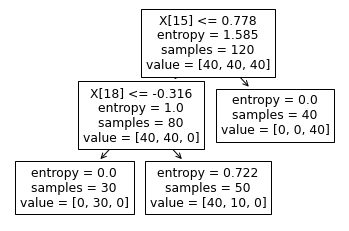

In [27]:
from sklearn.tree import plot_tree
plot_tree(model)

<h2>Confusion Matrix
</h2>

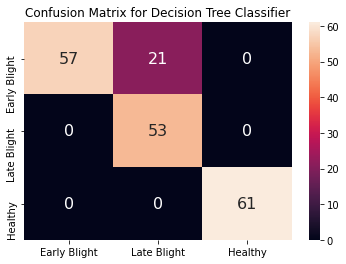

In [34]:
plot_matrix(y_test,predictions,'./images/All features/Decision Tree/ConfMatrixDTree.png')

<h2>ROC Curve</h2>

0: 78
1 :53
2 :61


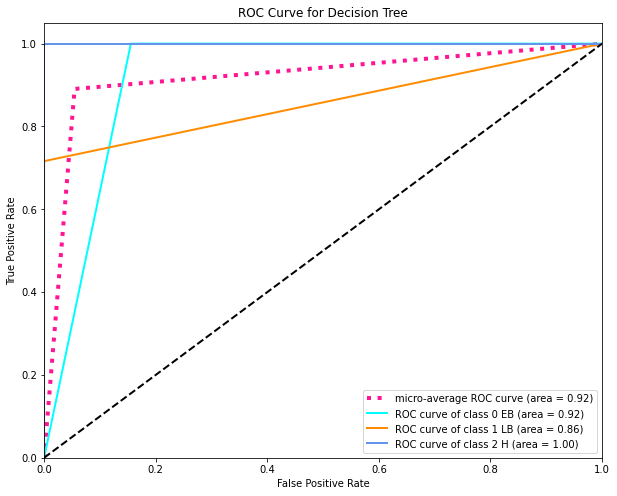

In [47]:
plot_roc(y_test,predictions,'./images/All features/Decision Tree/ROC_DTree.png')

<h2>Analysis of Decision Tree on research features</h2>

In [49]:
features=['Autocorrelation','Contrast','Correlation','Dissimilarity','Entropy',' Homogeneity','Homogeneity: [2]']
X_sub_train=X_train[features]
X_sub_test=X_test[features]

<h2>Hyper-parameter tuning</h2>

In [50]:
grid_s.fit(X_sub_train,y_train)

GridSearchCV(estimator=DecisionTreeClassifier(random_state=10),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 5, 6, 10, None],
                         'min_samples_leaf': [0.1, 0.2, 0.3, 0.4],
                         'min_samples_split': [0.1, 0.2, 0.3, 0.4, 2]})

In [51]:
print(grid_s.best_estimator_)
print(grid_s.best_params_)

DecisionTreeClassifier(max_depth=2, min_samples_leaf=0.1, min_samples_split=0.1,
                       random_state=10)
{'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 0.1, 'min_samples_split': 0.1}


In [52]:
model_sub=DecisionTreeClassifier(max_depth=2, min_samples_leaf=0.1, min_samples_split=0.1,
                       random_state=10)
model.fit(X_sub_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=2, min_samples_leaf=0.1,
                       min_samples_split=0.1, random_state=10)

In [53]:
predictions=model.predict(X_sub_test)

In [54]:
score(y_test,predictions)

              precision    recall  f1-score   support

           0       0.69      0.96      0.80        57
           1       1.00      0.66      0.80        74
           2       0.97      1.00      0.98        61

    accuracy                           0.86       192
   macro avg       0.89      0.88      0.86       192
weighted avg       0.90      0.86      0.86       192

0    80
2    63
1    49
dtype: int64
Accuracy score =0.859375


<h2>Confusion Matrix</h2>

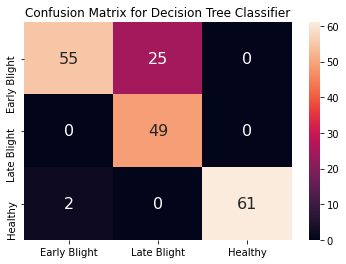

In [57]:
plot_matrix(y_test,predictions,'./images/Research Features/Decision Tree/ConfMatrixDTree.png')

<h2>ROC curve</h2>

0: 80
1 :49
2 :63


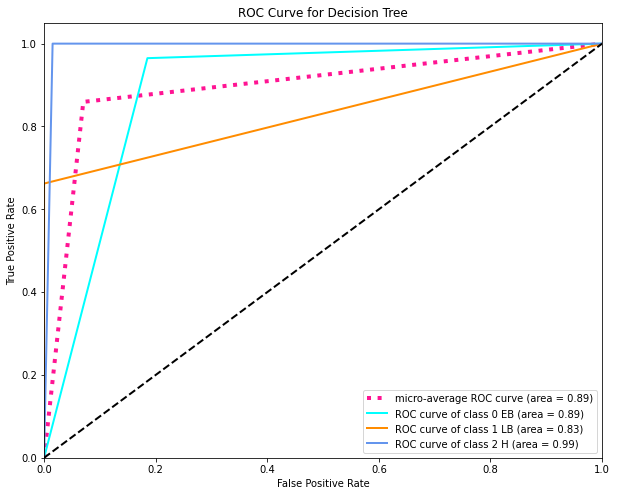

In [58]:
plot_roc(y_test,predictions,'./images/Research Features/Decision Tree/ROC_DTree.png')